# 00 · EDA, data audit and speaker-grouped folds

**Goal of this notebook:** understand the data before modelling, and build the two foundations every later notebook relies on:

1. **Zero gate**: a rule that recognises the noise-masked clips labelled 0, so the regressor is trained only on scorable speech.
2. **Pseudo-speaker groups and folds**: speakers repeat in train, and test speakers are unseen. Cross-validation must therefore keep each speaker in one fold, or the CV score rewards voice memorisation.

**Metric used throughout:** `composite = (RMSE + (1 − Pearson)) / 2`, lower is better. The leaderboard is "Pearson + RMSE"; this exact formula is inferred from public CV/LB pairs.

In [1]:
import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))                       # local run
for p in Path("/kaggle/input").glob("*/src"):               # Kaggle utility dataset
    sys.path.insert(0, str(p))
os.environ.setdefault("SHL_DATA", str(ROOT / "shl-hiring-assessment-2026"))

from shl import audio, data, embed, folds, metrics

OUT = Path("/kaggle/working") if Path("/kaggle/working").exists() else ROOT / "artifacts"
OUT.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

C:\Users\Tanmay\anaconda3\envs\shl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Metadata
Clips are keyed by `uid = split/file` because train and test reuse 212 file names for **different** recordings.

In [2]:
DATA = data.find_data_dir()
meta = data.load_metadata(DATA)
print(DATA)
print(meta.groupby("split").size())
shared = set(meta.query("split=='train'").file) & set(meta.query("split=='test'").file)
print("file names present in both splits:", len(shared))
sample = pd.read_csv(DATA / "sample_submission.csv")
in_test = sample.iloc[:, 0].isin(meta[meta.split == "test"].file).sum()
print(f"sample_submission rows: {len(sample)}, of which in test.csv: {in_test}"
      " -> the submission is built from test.csv instead")
meta.drop(columns=['uid', 'file', 'path', 'label']).head(0)   # schema only: no clip-level data in outputs

C:\Users\Tanmay\OneDrive\Desktop\shl intern\shl-hiring-assessment-2026\Dataset_Final
split
test     216
train    769
dtype: int64
file names present in both splits: 212
sample_submission rows: 204, of which in test.csv: 25 -> the submission is built from test.csv instead


## 2 · Label distribution
The rubric defines scores 1–5. Note the separate spike at **0**, and how few clips fall below 2.

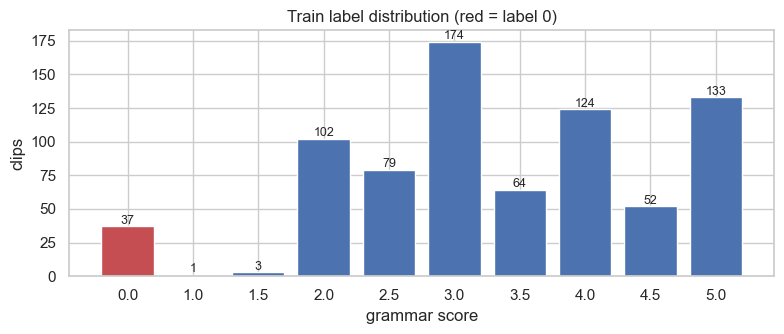

count    769.000
mean       3.313
std        1.239
min        0.000
25%        2.500
50%        3.000
75%        4.000
max        5.000
Name: label, dtype: float64


In [3]:
train = meta.query("split=='train'")
fig, ax = plt.subplots(figsize=(8, 3.5))
counts = train.label.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color=["#c44e52" if v == 0 else "#4c72b0" for v in counts.index])
for x, v in zip(range(len(counts)), counts.values):
    ax.text(x, v + 2, v, ha="center", fontsize=9)
ax.set(title="Train label distribution (red = label 0)", xlabel="grammar score", ylabel="clips")
plt.tight_layout(); plt.show()
print(train.label.describe().round(3))

## 3 · Signal-level quality features
Computed on the **raw** waveform (no normalisation), so clipping and flat noise stay visible.

In [4]:
qc_path = OUT / "qc_features.csv"
if qc_path.exists():
    qc = pd.read_csv(qc_path)
else:
    qc = pd.DataFrame([audio.qc_features(audio.load_raw(p)) for p in tqdm(meta.path, desc="QC")])
    qc.insert(0, "uid", meta.uid.values)
    qc.to_csv(qc_path, index=False)
meta = meta.merge(qc, on="uid")
meta.groupby("split")[["duration_s", "peak", "dynamic_range_db", "spectral_flatness", "silence_ratio"]].describe().T.round(2)

split                      test   train
duration_s        count  216.00  769.00
                  mean    48.76   55.78
                  std      8.18    7.91
                  min      6.48   20.06
                  25%     45.06   54.19
                  50%     45.06   60.07
                  75%     60.01   60.07
                  max     61.03   61.04
peak              count  216.00  769.00
                  mean     0.61    0.75
                  std      0.32    0.25
                  min      0.04    0.04
                  25%      0.28    0.64
                  50%      0.68    0.84
                  75%      0.92    0.95
                  max      1.00    1.00
dynamic_range_db  count  216.00  769.00
                  mean    45.50   48.61
                  std     23.52   21.32
                  min     12.28    3.66
                  25%     32.15   37.42
                  50%     42.03   47.61
                  75%     54.80   57.71
                  max    148.41  145.52
spectral_flatness count  216.00  769.00
                  mean     0.05    0.07
                  std      0.05    0.11
                  min      0.00    0.00
                  25%      0.02    0.02
                  50%      0.04    0.03
                  75%      0.06    0.07
                  max      0.36    0.53
silence_ratio     count  216.00  769.00
                  mean     0.26    0.32
                  std      0.17    0.17
                  min      0.00    0.00
                  25%      0.15    0.25
                  50%      0.28    0.34
                  75%      0.36    0.42
                  max      0.80    0.97

### 3a · Duration shift
Test clips are noticeably shorter than train clips. Consequences:
- absolute counts (number of words, total pause time) are replaced by **rates**;
- learned heads train on **random ~45 s crops** so they see test-like lengths.

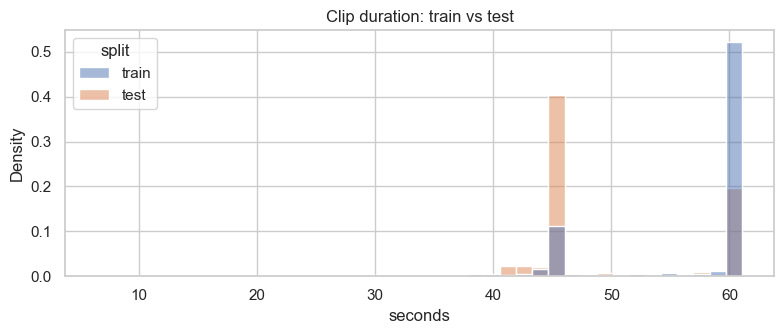

split
test     45.060000
train    60.074688
Name: duration_s, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(data=meta, x="duration_s", hue="split", bins=40, stat="density", common_norm=False, ax=ax)
ax.set(title="Clip duration: train vs test", xlabel="seconds")
plt.tight_layout(); plt.show()
print(meta.groupby("split").duration_s.median())

### 3b · Zero gate
The label-0 clips should separate cleanly on loudness dynamics: masking noise is stationary, so its dynamic range is tiny; real speech is bursty.

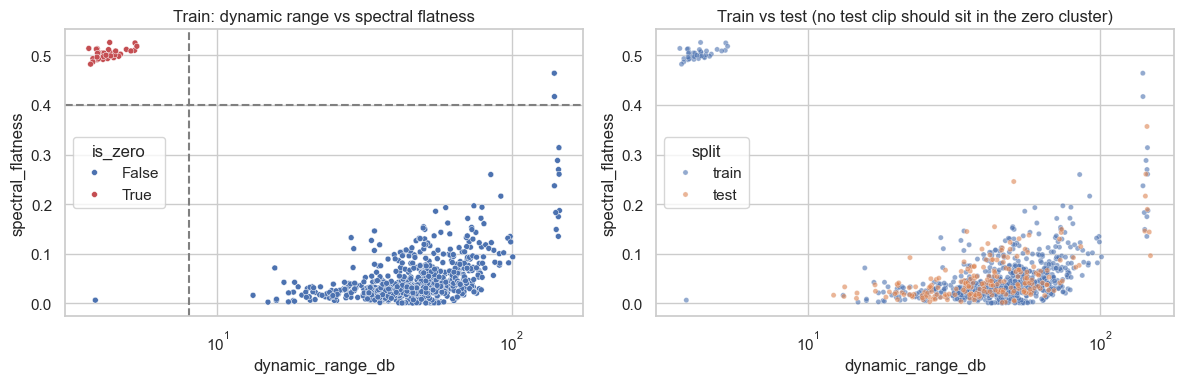

is_zero                   False  True 
dynamic_range_db  count  732.00  37.00
                  mean    50.85   4.28
                  std     19.32   0.44
                  min      3.85   3.66
                  25%     39.54   3.94
                  50%     48.77   4.19
                  75%     58.54   4.45
                  max    145.52   5.33
peak              count  732.00  37.00
                  mean     0.74   0.95
                  std      0.25   0.00
                  min      0.04   0.95
                  25%      0.62   0.95
                  50%      0.82   0.95
                  75%      0.94   0.95
                  max      1.00   0.95
spectral_flatness count  732.00  37.00
                  mean     0.05   0.50
                  std      0.05   0.01
                  min      0.00   0.48
                  25%      0.02   0.50
                  50%      0.03   0.50
                  75%      0.06   0.51
                  max      0.46   0.53
duration_s        count  

In [6]:
meta["is_zero"] = meta.label.eq(0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tr = meta.query("split=='train'")
sns.scatterplot(data=tr, x="dynamic_range_db", y="spectral_flatness", hue="is_zero", palette={False: "#4c72b0", True: "#c44e52"},
                s=18, ax=axes[0])
axes[0].set(title="Train: dynamic range vs spectral flatness", xscale="log")
axes[0].axhline(0.40, ls="--", c="grey"); axes[0].axvline(8, ls="--", c="grey")
sns.scatterplot(data=meta, x="dynamic_range_db", y="spectral_flatness", hue="split", s=14, alpha=.6, ax=axes[1])
axes[1].set(title="Train vs test (no test clip should sit in the zero cluster)", xscale="log")
plt.tight_layout(); plt.show()
print(tr.groupby("is_zero")[["dynamic_range_db", "peak", "spectral_flatness", "duration_s"]].describe().T.round(2))

In [7]:
# Two conditions, both needed: noise-like spectrum (flatness) AND stationary
# loudness (dynamic range). The public rule (range < 5 dB, peak > 0.9) misses
# 4 of the 37 zeros here; each condition alone has a thin or no margin.
GATE = dict(min_flatness=0.40, max_dynamic_range_db=8.0)
meta["gate"] = audio.zero_gate(meta, **GATE)
cm = pd.crosstab(meta.query("split=='train'").is_zero, meta.query("split=='train'").gate,
                 rownames=["label==0"], colnames=["gate fires"])
display(cm)
n_test_gate = int(meta.query("split=='test'").gate.sum())
print("test clips flagged by the gate:", n_test_gate)
if cm.values.trace() != len(tr):
    print("WARNING: gate is not perfect on train -> revisit thresholds before continuing")

gate fires,False,True
label==0,,
False,732,0
True,0,37


test clips flagged by the gate: 0


## 4 · Pseudo-speakers
There are no speaker IDs, so they are approximated. Every clip is embedded with a **speaker-verification** model (`microsoft/wavlm-base-plus-sv`, x-vectors), then clustered by cosine distance.

Two lessons from the data:
- **Mean-centring is essential.** Raw x-vectors share a large common component, so the median nearest-neighbour cosine is ~0.98 and everything merges into a few giant clusters.
- **Pick the threshold by leakage, not by cluster purity.** What CV needs is that likely same-speaker pairs never sit in different folds. Mixed groups are harmless as long as folds stay balanced.

In [8]:
emb_path = OUT / "speaker_emb.npy"
if emb_path.exists():
    spk = np.load(emb_path)
else:
    spk = embed.speaker_embeddings(meta.path.tolist())
    np.save(emb_path, spk)
is_tr = (meta.split == "train").values
scorable = is_tr & ~meta.is_zero.values
center = spk[scorable].mean(0)                      # centre on train only
Z_tr = folds.prepare_embeddings(spk[scorable], center)
Z_all = folds.prepare_embeddings(spk, center)
y_sc = meta.label.values[scorable]
print(spk.shape)

(985, 512)


### 4a · Do speakers repeat with the same score?
If they do, a clip's most similar other clip should usually carry the same label. This is the evidence that random K-fold would leak.

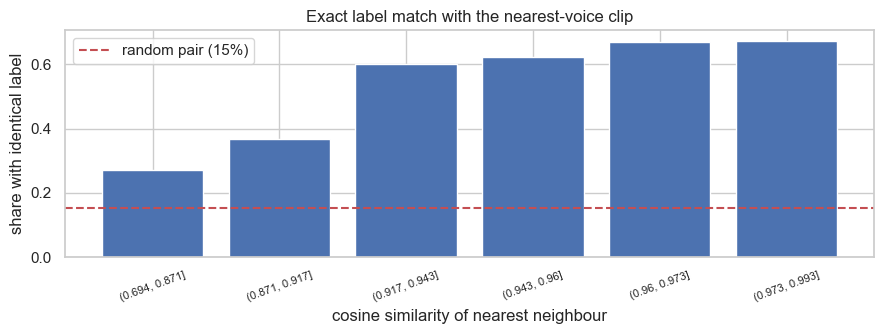

,mean_abs_dy,exact_match
similarity bin,,
"(0.694, 0.871]",0.803,0.270
"(0.871, 0.917]",0.574,0.369
"(0.917, 0.943]",0.313,0.602
"(0.943, 0.96]",0.311,0.623
"(0.96, 0.973]",0.190,0.669
"(0.973, 0.993]",0.250,0.672


random pairs: mean |dy| = 1.20


In [9]:
S = Z_tr @ Z_tr.T; np.fill_diagonal(S, -1)
nn, sim = S.argmax(1), S.max(1)
agree = pd.DataFrame({"sim": sim, "abs_dy": np.abs(y_sc - y_sc[nn]), "same": y_sc == y_sc[nn]})
agree["similarity bin"] = pd.qcut(agree.sim, 6).astype(str)
tab = agree.groupby("similarity bin", sort=False).agg(mean_abs_dy=("abs_dy", "mean"), exact_match=("same", "mean")).sort_index()
rng = np.random.default_rng(SEED); r = rng.permutation(len(y_sc))
base_dy, base_match = np.abs(y_sc - y_sc[r]).mean(), (y_sc == y_sc[r]).mean()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(tab)), tab.exact_match, color="#4c72b0")
ax.axhline(base_match, ls="--", c="#c44e52", label=f"random pair ({base_match:.0%})")
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index, rotation=20, fontsize=8)
ax.set(title="Exact label match with the nearest-voice clip", ylabel="share with identical label", xlabel="cosine similarity of nearest neighbour")
ax.legend(); plt.tight_layout(); plt.show()
display(tab.round(3)); print(f"random pairs: mean |dy| = {base_dy:.2f}")

### 4b · Choosing the threshold
`pair_leak` is the share of likely same-speaker pairs (cosine > 0.93) split into different groups. We take the lowest-leak threshold whose largest group is at most 6% of clips, which keeps balanced 5-fold splits possible.

,threshold,n_groups,largest_group,pair_leak
0,0.100,395,9,0.099537
1,0.125,343,15,0.057870
2,0.150,289,23,0.034722
3,0.175,247,36,0.027778
4,0.200,212,40,0.025463
5,0.225,175,44,0.025463
6,0.250,143,77,0.011574
7,0.275,124,77,0.009259
8,0.300,101,78,0.009259
9,0.325,88,78,0.009259


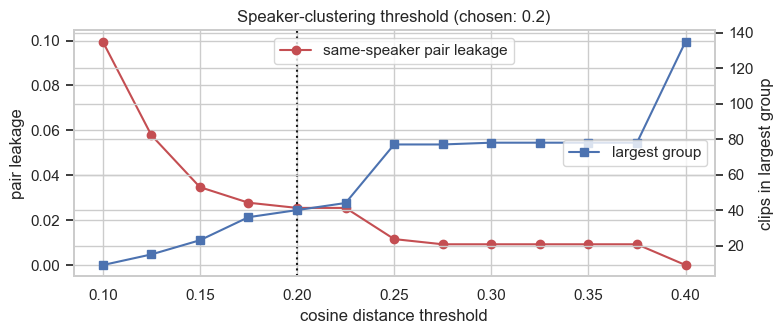

In [10]:
sweep = folds.threshold_sweep(Z_tr, y_sc, np.round(np.arange(0.10, 0.42, 0.025), 3))
THRESH = folds.choose_threshold(sweep, n=len(y_sc))
display(sweep)
fig, ax1 = plt.subplots(figsize=(8, 3.5))
ax1.plot(sweep.threshold, sweep.pair_leak, "o-", color="#c44e52", label="same-speaker pair leakage")
ax1.set(xlabel="cosine distance threshold", ylabel="pair leakage")
ax2 = ax1.twinx(); ax2.plot(sweep.threshold, sweep.largest_group, "s-", color="#4c72b0", label="largest group"); ax2.set_ylabel("clips in largest group")
ax1.axvline(THRESH, ls=":", c="k"); ax1.set_title(f"Speaker-clustering threshold (chosen: {THRESH})")
ax1.legend(loc="upper center"); ax2.legend(loc="center right"); plt.tight_layout(); plt.show()

In [11]:
meta["group"] = -1
meta.loc[scorable, "group"] = folds.cluster_speakers(Z_tr, THRESH)
# Joint clustering of train+test, used only to study test structure and,
# in Tier 3, to test smoothing predictions within test-speaker clusters.
meta["group_all"] = folds.cluster_speakers(Z_all, THRESH)
gs = meta[scorable | ~is_tr].groupby("group_all").split.agg(lambda s: frozenset(s))
print("joint groups:", len(gs), "| train-only:", sum(s == {"train"} for s in gs),
      "| test-only:", sum(s == {"test"} for s in gs), "| mixed:", sum(s == {"train", "test"} for s in gs))
S_te_tr = Z_all[~is_tr] @ Z_tr.T
S_te = Z_all[~is_tr] @ Z_all[~is_tr].T; np.fill_diagonal(S_te, -1)
print(f"test clips whose nearest train clip has cosine > 0.93 (likely seen speaker): {(S_te_tr.max(1) > .93).mean():.1%}")
print(f"test clips with another test clip at cosine > 0.93 (repeat test speaker):   {(S_te.max(1) > .93).mean():.1%}")
print(f"train clips with another train clip at cosine > 0.93 (reference):          {(sim > .93).mean():.1%}")

joint groups: 273 | train-only: 151 | test-only: 54 | mixed: 68
test clips whose nearest train clip has cosine > 0.93 (likely seen speaker): 8.8%
test clips with another test clip at cosine > 0.93 (repeat test speaker):   22.7%
train clips with another train clip at cosine > 0.93 (reference):          60.2%


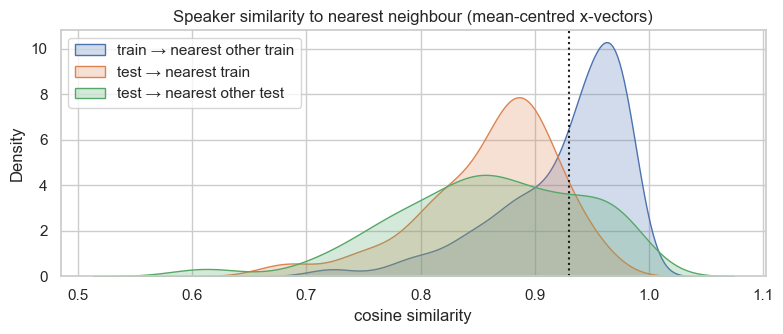

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for v, lab in [(sim, "train → nearest other train"), (S_te_tr.max(1), "test → nearest train"),
               (S_te.max(1), "test → nearest other test")]:
    sns.kdeplot(v, ax=ax, label=lab, fill=True, alpha=.25)
ax.axvline(.93, ls=":", c="k")
ax.set(title="Speaker similarity to nearest neighbour (mean-centred x-vectors)", xlabel="cosine similarity"); ax.legend()
plt.tight_layout(); plt.show()

## 5 · Folds
5 folds × 5 seeds on the 732 scorable clips. A greedy assigner places whole pseudo-speaker groups, balancing fold **size** and **score distribution**. sklearn's `StratifiedGroupKFold` gave folds of 99–196 clips on this data. The assert guarantees no group spans two folds; the leakage line measures what remains from imperfect clustering.

In [13]:
fit_df = meta[scorable].reset_index(drop=True)
fold_df = folds.make_folds(fit_df.label.values, fit_df.group.values, n_splits=5, seeds=(0, 1, 2, 3, 4))
a, b = folds.same_speaker_pairs(Z_tr)
leak = np.mean([(fold_df[c].values[a] != fold_df[c].values[b]).mean() for c in fold_df.columns])
print(f"likely same-speaker pairs: {len(a)}, of which split across folds: {leak:.1%} (random 5-fold would split ~80%)")
fold_df.insert(0, "uid", fit_df.uid.values)
display(pd.DataFrame({c: fold_df[c].value_counts().sort_index() for c in fold_df.columns[1:]}))
display(fit_df.groupby(fold_df.fold_s0.values).label.agg(["count", "mean", "std"]).round(2))

likely same-speaker pairs: 432, of which split across folds: 1.9% (random 5-fold would split ~80%)


,fold_s0,fold_s1,fold_s2,fold_s3,fold_s4
0,147,145,147,146,147
1,146,146,147,147,146
2,146,147,146,146,147
3,146,147,147,147,146
4,147,147,145,146,146


,count,mean,std
0,147,3.48,1.00
1,146,3.52,1.02
2,146,3.45,1.04
3,146,3.47,1.03
4,147,3.48,0.99


In [14]:
meta.to_csv(OUT / "meta.csv", index=False)
fold_df.to_csv(OUT / "folds.csv", index=False)
print("saved:", OUT / "meta.csv", OUT / "folds.csv")

saved: C:\Users\Tanmay\OneDrive\Desktop\shl intern\artifacts\meta.csv C:\Users\Tanmay\OneDrive\Desktop\shl intern\artifacts\folds.csv


## Summary
- **Zero gate:** two conditions (flatness > 0.40, dynamic range < 8 dB) flag all 37 label-0 clips, no scorable train clip and no test clip. The public rule (range < 5 dB, peak > 0.9) missed 4. Gated clips are scored 0; the regressor trains on the 732 scorable clips.
- **Duration shift:** train ≈ 60 s, test ≈ 45 s. Features use rates, and learned heads train on 40–50 s crops.
- **Speakers repeat:** a clip's nearest voice shares its exact label far more often than chance. Folds are built from pseudo-speaker groups, and the residual leakage is measured above.
- **Test structure:** the share of test clips with a likely repeat test speaker decides whether test-speaker smoothing (Tier 3) is worth testing.